---
---
# Análisis de Eficiencia Ofensiva De los Tiros a los Goles en las 5 Grandes Ligas Europeas
---
---

# 1. Descripción General del Proyecto

### 1.1 Introducción
El fútbol moderno se caracteriza por la búsqueda constante de ventajas competitivas a través del análisis de datos. Mientras que la predicción de resultados es una aplicación valiosa, entender los procesos subyacentes que generan esos resultados es igualmente crucial. Este proyecto se enfoca en analizar la relación entre el volumen ofensivo (tiros) y la eficiencia en la conversión a goles en las cinco principales ligas europeas de fútbol.

### 1.2 Hipótesis Central
Los equipos dominantes no solo generan más volumen ofensivo (tiros), sino que son más eficientes en convertir ese volumen en resultados (goles). Este análisis busca cuantificar esa eficiencia y determinar su relación con el éxito deportivo.

### 1.3 Objetivos del Proyecto
- Calcular métricas de eficiencia ofensiva (goles por tiro, goles por tiro a puerta) por equipo y temporada
- Comparar la eficiencia de equipos dominantes vs. equipos promedio
- Analizar la evolución temporal de la eficiencia ofensiva
- Relacionar métricas de eficiencia con resultados competitivos (puntos obtenidos)
- Identificar patrones específicos por liga y país

### 1.4 Alcance del Proyecto
- Análisis de las 5 grandes ligas europeas (Premier League, La Liga, Bundesliga, Serie A, Ligue 1)
- Período: 2000-2025 (según disponibilidad de datos)
- Enfoque en métricas pre-partido para evitar data leakage
- Análisis descriptivo y comparativo

---

# 2. Carga y Descripción de Datos

### 2.1 Carga de Librerías

In [1]:
# Reutilizamos las librerías del proyecto anterior
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

### 2.2 Carga de Datos

In [ ]:
# Carga de los Dataset
elo = pd.read_csv("Data\EloRatings.csv")
matches = pd.read_csv("Data\Matches.csv", low_memory=False)

In [3]:
# Función de diagnóstico (reutilizada)
def fun_diagnóstico(df):
    print("ESTRUCTURA GENERAL")
    print(df.shape)
    print("\nCOLUMNAS Y TIPOS DE DATOS")
    print(df.info())
    print("\nMUESTRA DE LOS DATOS")
    print(df.sample(5))
    print("\nVALORES NULOS POR COLUMNA")
    print(df.isnull().sum().sort_values(ascending=False).head(15))

### 2.3 Diagnóstico Inicial

In [4]:
# LLamada a la función de diagnóstico inicial de datos
print(" === Elo Ratings === ")
fun_diagnóstico (elo)

 === Elo Ratings === 
ESTRUCTURA GENERAL
(242591, 4)

COLUMNAS Y TIPOS DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242591 entries, 0 to 242590
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   date     242591 non-null  object 
 1   club     242591 non-null  object 
 2   country  242591 non-null  object 
 3   elo      242591 non-null  float64
dtypes: float64(1), object(3)
memory usage: 7.4+ MB
None

MUESTRA DE LOS DATOS
              date           club country      elo
189473  2019-10-15    Southampton     ENG  1660.67
52129   2005-11-15           Lech     POL  1358.38
75528   2008-04-01          Porto     POR  1824.85
241648  2025-02-01  Panathinaikos     GRE  1574.42
98106   2010-07-15   Panserraikos     GRE  1272.87

VALORES NULOS POR COLUMNA
date       0
club       0
country    0
elo        0
dtype: int64


In [5]:
print(" === Matches === ")
fun_diagnóstico (matches)

 === Matches === 
ESTRUCTURA GENERAL
(228377, 42)

COLUMNAS Y TIPOS DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228377 entries, 0 to 228376
Data columns (total 42 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     228377 non-null  object 
 1   MatchDate    228377 non-null  object 
 2   MatchTime    96892 non-null   object 
 3   HomeTeam     228377 non-null  object 
 4   AwayTeam     228377 non-null  object 
 5   HomeElo      139910 non-null  float64
 6   AwayElo      139842 non-null  float64
 7   Form3Home    226877 non-null  float64
 8   Form5Home    226877 non-null  float64
 9   Form3Away    226877 non-null  float64
 10  Form5Away    226877 non-null  float64
 11  FTHome       228374 non-null  float64
 12  FTAway       228374 non-null  float64
 13  FTResult     228374 non-null  object 
 14  HTHome       173797 non-null  float64
 15  HTAway       173797 non-null  float64
 16  HTResult     173797 non-null  obj

Observaciones:

El proyecto se sustenta en dos fuentes de datos masivas que, al combinarse, permiten un análisis multidimensional (técnico y de rendimiento).

- Dataset Elo Ratings: Contiene 242,591 registros. La columna Elo es el núcleo de nuestra clasificación de "Dominancia", permitiendo trackear el nivel de poderío de cada club (club) a través del tiempo (date).

- Dataset de Partidos (Matches): Con 228,377 entradas, es una base de datos de alta granularidad. Aunque abarca desde la temporada 2000/01, nuestro análisis se centrará en la Era Moderna (2012-2025) para asegurar la consistencia en las estadísticas de tiros y tiros a puerta, que son fundamentales para nuestras métricas de eficiencia.

### 2.4 Selección de Columnas Relevantes
Para el análisis de eficiencia ofensiva, necesitamos:

- Información de tiros (totales y a puerta)
- Información de goles
- Identificación de equipos y ligas
- Fecha para análisis temporal

In [6]:
# Columnas específicas para análisis ofensivo
offensive_columns = matches[[
    'MatchDate', 'Division', 'HomeTeam', 'AwayTeam',
    'HomeShots', 'AwayShots', 'HomeTarget', 'AwayTarget',
    'FTHome', 'FTAway'
]]

# Renombrar columnas para mejor comprensión semántica
offensive_data = offensive_columns.rename(columns={
    'MatchDate': 'date',
    'Division': 'division',
    'HomeTeam': 'home_team',
    'AwayTeam': 'away_team',
    'HomeShots': 'home_shots',
    'AwayShots': 'away_shots',
    'HomeTarget': 'home_target',
    'AwayTarget': 'away_target',
    'FTHome': 'full_time_home_goals',
    'FTAway': 'full_time_away_goals',
})

print("=== DATOS OFENSIVOS - ESTRUCTURA ===")
print(f"Registros totales: {len(offensive_data)}")
print(f"Columnas: {offensive_data.columns.tolist()}")
print(f"Rango temporal: {offensive_data['date'].min()} a {offensive_data['date'].max()}")

=== DATOS OFENSIVOS - ESTRUCTURA ===
Registros totales: 228377
Columnas: ['date', 'division', 'home_team', 'away_team', 'home_shots', 'away_shots', 'home_target', 'away_target', 'full_time_home_goals', 'full_time_away_goals']
Rango temporal: 2000-07-28 a 2025-02-26


In [7]:
# Función para calcular el % de valores nulos por columna
def null_data(df):
    total_filas = len(df)
    nulos = df.isnull().sum()
    porcentaje = (nulos / total_filas * 100).round(2)
    return porcentaje[porcentaje > 0]

# Aplicación de la funcion
print("=== VALORES NULOS EN DATOS OFENSIVOS ===")
print(null_data(offensive_data))

=== VALORES NULOS EN DATOS OFENSIVOS ===
home_shots     50.72
away_shots     50.71
home_target    51.07
away_target    51.07
dtype: float64


Observaciones:
Si bien el dataset de partidos es rico en dimensiones, presenta un desafío significativo: aproximadamente el 50% de los datos de tiros y tiros a puerta están ausentes. Ya que el dataset cuenta con ligas, temporadas y equipos, es posible que los nulos estén concentrados en ciertas ligas o temporadas específicas.

Esta limitación requerirá una estrategia de limpieza e imputación cuidadosa para no comprometer el análisis de eficiencia ofensiva que es el corazón del proyecto.


# Plan de Acción

- Las columnas date en ambos datasets se convertirán al tipo datetime.
- Filtrado del dataset matches solo para las 5 principales ligas de Europa (Premier, La Liga, Bundesliga, Serie A, Ligue 1).
- Enriquecimiento semantico del dataset para mejor lectura enfocado en el país y nombre de la liga.
- integracion del rating elo al dataset filtrado con las 5 ligas de estudio para el análisis.
- Eliminación o imputación de valores nulos en el dataset.
- Creación de metricas necesarias para el análisis.
- Análisis Comparativo entre Ligas.
- Evolución Temporal.
- Análisis por equipo (Top Performers).

---
# 3. Procesamiento y Limpieza de Datos

### 3.1 Conversión de columnas al tipo de dato adecuado

In [8]:
# Convertir fecha
offensive_data['date'] = pd.to_datetime(offensive_data['date'])
offensive_data = offensive_data.sort_values('date').reset_index(drop=True)
elo['date'] = pd.to_datetime(elo['date'])

In [9]:
offensive_data.head()

,date,division,home_team,away_team,home_shots,away_shots,home_target,away_target,full_time_home_goals,full_time_away_goals
0,2000-07-28,F1,Marseille,Troyes,NaN,NaN,NaN,NaN,3.0,1.0
1,2000-07-28,F1,Paris SG,Strasbourg,NaN,NaN,NaN,NaN,3.0,1.0
2,2000-07-28,F2,Wasquehal,Nancy,NaN,NaN,NaN,NaN,0.0,1.0
3,2000-07-29,F1,Toulouse,Bastia,NaN,NaN,NaN,NaN,0.0,1.0
4,2000-07-29,F1,Nantes,Lens,NaN,NaN,NaN,NaN,0.0,2.0


### 3.2 Filtrado las 5 Grandes Ligas Europeas

In [10]:
# Códigos de las 5 grandes ligas
main_leagues = ['E0', 'SP1', 'D1', 'I1', 'F1']  # Premier, La Liga, Bundesliga, Serie A, Ligue 1

# Filtrar datos
offensive_data = offensive_data[offensive_data['division'].isin(main_leagues)].copy()

print("=== DISTRIBUCIÓN POR LIGA ===")
distribucion = offensive_data['division'].value_counts()
print(distribucion)
print(f"\nTotal partidos en grandes ligas: {len(offensive_data)}")
print(f"Porcentaje del total: {(len(offensive_data)/len(offensive_data)*100):.1f}%")

=== DISTRIBUCIÓN POR LIGA ===
division
E0     9300
I1     8891
SP1    8878
F1     8657
D1     7423
Name: count, dtype: int64

Total partidos en grandes ligas: 43149
Porcentaje del total: 100.0%


### 3.3 Funciones para el enriquecimiento Semántico de los datasets

In [11]:
# Función que agrupa Ligas por País a partir de la columna 'division' en el dataset
def map_country(x):
    if x in ['F1']:
        return 'France'
    elif x in ['D1']:
        return 'Germany'
    elif x in ['E0']:
        return 'England'
    elif x in ['I1']:
        return 'Italy'
    elif x in ['SP1']:
        return 'Spain'
    else:
        return 'Other'
    
# Función para mapear nombres semánticos de las ligas ['E0', 'SP1', 'D1', 'I1', 'F1']
def map_league_name(x):
    if x == 'E0':
        return 'Premier League'
    elif x == 'F1':
        return 'Ligue 1'
    elif x == 'D1':
        return 'Bundesliga'
    elif x == 'I1':
        return 'Serie A'
    elif x == 'SP1':
        return 'La Liga'
    else:
        return 'Other'
    
# Función semántica para estandarizar países en el dataset Elo
def map_country_elo(x):
    if x == 'ENG':
        return 'England'
    elif x == 'ESP':
        return 'Spain'
    elif x == 'GER':
        return 'Germany'
    elif x == 'ITA':
        return 'Italy'
    elif x == 'FRA':
        return 'France'
    else:
        return 'Other'
    

In [12]:
# Aplicacion de las funciones para mejor lectura semántica en ...
offensive_data['league_name'] = offensive_data['division'].apply(map_league_name)
offensive_data['country'] = offensive_data['division'].apply(map_country)

# Aplicación la función semantica al dataset Elo
elo['country'] = elo['country'].apply(map_country_elo)

### 3.5 Integración de Elo Rating

Elo asigna a cada equipo un rating que:
- sube si ganas
- baja si pierdes
- depende de la fuerza del rival

Elo pre-partido para:
- equipo local
- equipo visitante
- diferencia de Elo

Regla de oro:  `El Elo usado en un partido solo puede depender de partidos anteriores`

In [13]:
offensive_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43149 entries, 0 to 228376
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  43149 non-null  datetime64[ns]
 1   division              43149 non-null  object        
 2   home_team             43149 non-null  object        
 3   away_team             43149 non-null  object        
 4   home_shots            38236 non-null  float64       
 5   away_shots            38236 non-null  float64       
 6   home_target           37430 non-null  float64       
 7   away_target           37430 non-null  float64       
 8   full_time_home_goals  43149 non-null  float64       
 9   full_time_away_goals  43149 non-null  float64       
 10  league_name           43149 non-null  object        
 11  country               43149 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(5)
memory usage: 4.3+ MB


In [14]:
# Renombrar 'club' a 'team' en elo dataset
elo = elo.rename(columns={'club': 'team'})

# Ordenar AMBOS DataFrames por la columna (date)
offensive_sorted = offensive_data.sort_values('date')
elo_clean = elo.sort_values('date')

In [15]:
# ELO local
matches_enriched = pd.merge_asof(
    offensive_sorted, 
    elo_clean[['date', 'team', 'elo']], 
    left_on='date', 
    right_on='date', 
    left_by='home_team', 
    right_by='team', 
    direction='backward'
)

# Renombramos y eliminamos columna redundante
matches_enriched = matches_enriched.rename(columns={'elo': 'elo_home'}).drop(columns=['team'])

matches_enriched

,date,division,home_team,away_team,home_shots,away_shots,home_target,away_target,full_time_home_goals,full_time_away_goals,league_name,country,elo_home
0,2000-07-28,F1,Marseille,Troyes,NaN,NaN,NaN,NaN,3.0,1.0,Ligue 1,France,1686.34
1,2000-07-28,F1,Paris SG,Strasbourg,NaN,NaN,NaN,NaN,3.0,1.0,Ligue 1,France,1714.89
2,2000-07-29,F1,Toulouse,Bastia,NaN,NaN,NaN,NaN,0.0,1.0,Ligue 1,France,1551.65
3,2000-07-29,F1,Nantes,Lens,NaN,NaN,NaN,NaN,0.0,2.0,Ligue 1,France,1664.36
4,2000-07-29,F1,Lyon,Rennes,NaN,NaN,NaN,NaN,2.0,2.0,Ligue 1,France,1702.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43144,2025-02-26,E0,Man United,Ipswich,10.0,12.0,6.0,3.0,3.0,2.0,Premier League,England,1757.62
43145,2025-02-26,E0,Nott'm Forest,Arsenal,6.0,13.0,2.0,1.0,0.0,0.0,Premier League,England,1788.28
43146,2025-02-26,E0,Tottenham,Man City,11.0,12.0,6.0,5.0,0.0,1.0,Premier League,England,1785.53
43147,2025-02-26,E0,Brentford,Everton,12.0,14.0,3.0,4.0,1.0,1.0,Premier League,England,1738.05


In [16]:
# Creacion del Elo Visitante
matches_enriched = pd.merge_asof(
    matches_enriched, 
    elo_clean[['date', 'team', 'elo']], 
    left_on='date', 
    right_on='date', 
    left_by='away_team', 
    right_by='team', 
    direction='backward'
)

# Renombramos y eliminamos columna redundante
matches_enriched = matches_enriched.rename(columns={'elo': 'elo_away'}).drop(columns=['team'])

matches_enriched.head(5)

,date,division,home_team,away_team,home_shots,away_shots,home_target,away_target,full_time_home_goals,full_time_away_goals,league_name,country,elo_home,elo_away
0,2000-07-28,F1,Marseille,Troyes,NaN,NaN,NaN,NaN,3.0,1.0,Ligue 1,France,1686.34,1586.57
1,2000-07-28,F1,Paris SG,Strasbourg,NaN,NaN,NaN,NaN,3.0,1.0,Ligue 1,France,1714.89,1642.51
2,2000-07-29,F1,Toulouse,Bastia,NaN,NaN,NaN,NaN,0.0,1.0,Ligue 1,France,1551.65,1656.37
3,2000-07-29,F1,Nantes,Lens,NaN,NaN,NaN,NaN,0.0,2.0,Ligue 1,France,1664.36,1730.89
4,2000-07-29,F1,Lyon,Rennes,NaN,NaN,NaN,NaN,2.0,2.0,Ligue 1,France,1702.60,1644.99


### 3.5 Crear Dataset Longitudinal por Equipo

Para analizar eficiencia, necesitamos datos a nivel equipo-partido

In [17]:
# Creación del dataset para equipos locales
home_stats = matches_enriched[['date', 'league_name', 'home_team', 
                                  'home_shots', 'home_target', 'full_time_home_goals', 'elo_home']].copy()

home_stats = home_stats.rename(columns={
    'home_team': 'team',
    'home_shots': 'shots',
    'home_target': 'shots_on_target',
    'full_time_home_goals': 'goals',
    'elo_home': 'elo'
})

# Creación de columna venue
home_stats['venue'] = 'home'

home_stats.head(5)

,date,league_name,team,shots,shots_on_target,goals,elo,venue
0,2000-07-28,Ligue 1,Marseille,NaN,NaN,3.0,1686.34,home
1,2000-07-28,Ligue 1,Paris SG,NaN,NaN,3.0,1714.89,home
2,2000-07-29,Ligue 1,Toulouse,NaN,NaN,0.0,1551.65,home
3,2000-07-29,Ligue 1,Nantes,NaN,NaN,0.0,1664.36,home
4,2000-07-29,Ligue 1,Lyon,NaN,NaN,2.0,1702.60,home


In [18]:
# Creación del dataset para equipos visitantes
away_stats = matches_enriched[['date', 'league_name', 'away_team', 
                                  'away_shots', 'away_target', 'full_time_away_goals', 'elo_away']].copy()
away_stats = away_stats.rename(columns={
    'away_team': 'team',
    'away_shots': 'shots',
    'away_target': 'shots_on_target',
    'full_time_away_goals': 'goals',
    'elo_away': 'elo'
})

# Creación de columna venue
away_stats['venue'] = 'away'

away_stats.head(5)


,date,league_name,team,shots,shots_on_target,goals,elo,venue
0,2000-07-28,Ligue 1,Troyes,NaN,NaN,1.0,1586.57,away
1,2000-07-28,Ligue 1,Strasbourg,NaN,NaN,1.0,1642.51,away
2,2000-07-29,Ligue 1,Bastia,NaN,NaN,1.0,1656.37,away
3,2000-07-29,Ligue 1,Lens,NaN,NaN,2.0,1730.89,away
4,2000-07-29,Ligue 1,Rennes,NaN,NaN,2.0,1644.99,away


In [19]:
# Combinación de home_stats y away_stats
team_matches = pd.concat([home_stats, away_stats], ignore_index=True)
team_matches = team_matches.sort_values(['team', 'date']).reset_index(drop=True)

print("=== DATOS POR EQUIPO-PARTIDO ===")
print(f"Registros totales: {len(team_matches)}")
print(f"Equipos únicos: {team_matches['team'].nunique()}")
print(f"Partidos por equipo (promedio): {len(team_matches)/team_matches['team'].nunique():.1f}")

=== DATOS POR EQUIPO-PARTIDO ===
Registros totales: 86298
Equipos únicos: 218
Partidos por equipo (promedio): 395.9


In [20]:
team_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86298 entries, 0 to 86297
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             86298 non-null  datetime64[ns]
 1   league_name      86298 non-null  object        
 2   team             86298 non-null  object        
 3   shots            76472 non-null  float64       
 4   shots_on_target  74860 non-null  float64       
 5   goals            86298 non-null  float64       
 6   elo              86258 non-null  float64       
 7   venue            86298 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 5.3+ MB


### 3.6 Limpieza Final

In [21]:
# Función para calcular el % de valores nulos
print("=== VALORES NULOS EN Team Matches ===")
print(null_data (team_matches))

=== VALORES NULOS EN Team Matches ===
shots              11.39
shots_on_target    13.25
elo                 0.05
dtype: float64


### 3.6.1 Analisis de datos nulos por temporada (para ver el factor tiempo)

In [22]:
# Agregar año de temporada (asumiendo temporada europea)
team_matches['year'] = team_matches['date'].dt.year
team_matches['month'] = team_matches['date'].dt.month
team_matches['season'] = team_matches.apply(
    lambda x: f"{x['year']-1}-{x['year']}" if x['month'] < 7 else f"{x['year']}-{x['year']+1}",
    axis=1
)

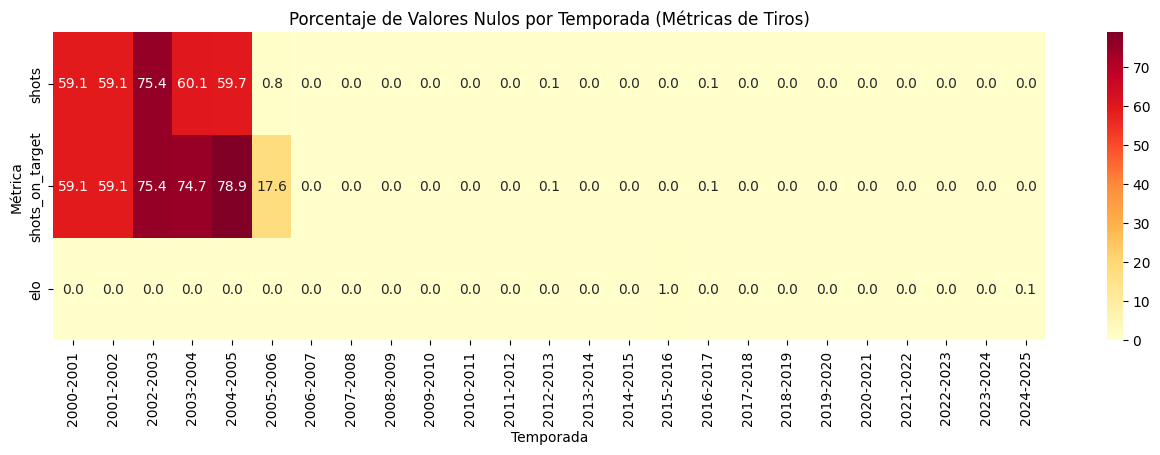

In [25]:
# Columnas con datos ausentes
null_cols = ['shots', 'shots_on_target', 'elo']

# Datos ausentes por temporada
nulls_by_season = team_matches.groupby('season')[null_cols].apply(lambda x: x.isnull().mean() * 100)

# Visualización Profesional: Heatmap de Nulos por Temporada
plt.figure(figsize=(16, 4))
sns.heatmap(nulls_by_season.T, annot=True, cmap='YlOrRd', fmt=".1f")
plt.title('Porcentaje de Valores Nulos por Temporada (Métricas de Tiros)')
plt.xlabel('Temporada')
plt.ylabel('Métrica')
plt.show()

### 3.6.2 Tabla de nulos por liga (para ver el factor fuente de datos)

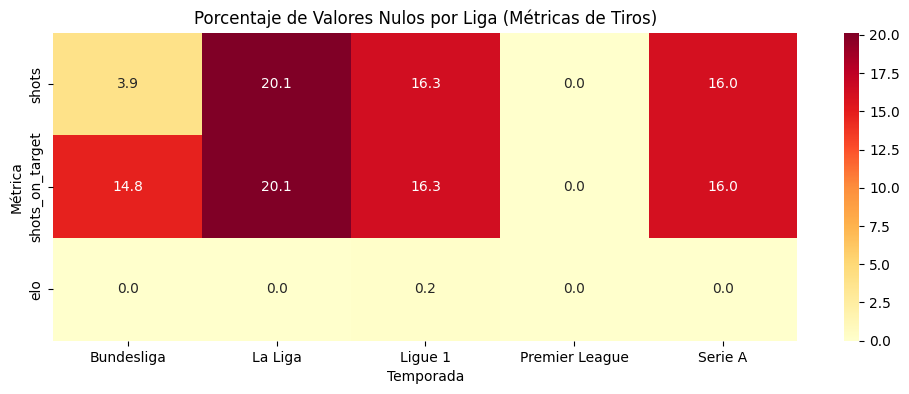

In [26]:
# Datos nulos por liga
nulls_by_league = team_matches.groupby('league_name')[null_cols].apply(lambda x: x.isnull().mean() * 100)

# Visualización Profesional: Heatmap de Nulos por liga
plt.figure(figsize=(12, 4))
sns.heatmap(nulls_by_league.T, annot=True, cmap='YlOrRd', fmt=".1f")
plt.title('Porcentaje de Valores Nulos por Liga (Métricas de Tiros)')
plt.xlabel('Temporada')
plt.ylabel('Métrica')
plt.show()

Observaviones clave:

El diagnóstico de calidad revela que la recolección de métricas avanzadas (tiros y tiros a puerta) no es uniforme en el tiempo. Mientras que los goles están presentes desde el año 2000, los tiros muestran un vacío importante. Se procede a identificar el año de corte donde la recolección se estabiliza para asegurar que las comparaciones de eficiencia sean estadísticamente válidas.

### 3.6.3 Selección del período de análisis final 2012-2025
Se determina que a partir de la temporada 2012 la cobertura de datos es adecuada para el análisis de eficiencia ofensiva. Por lo tanto, se filtran los datos para incluir solo partidos desde esta temporada en adelante. Esta decisión garantiza que las métricas de tiros y tiros a puerta sean suficientemente completas para evaluar la eficiencia de conversión a goles de manera confiable.

**El año 2012 es un punto de inflexión en la industria de los datos deportivos (coincide con el auge de empresas como Opta o Wyscout).**

In [27]:
# Corte del dataset con los años sin valores nulos
final_matches = team_matches[team_matches['season'] >= '2012'].copy()

print("=== Valores nulos después de corte ===")
print(null_data (final_matches))

# Valores nulos por Liga despues de corte
nulls_by_league_final = final_matches.groupby('league_name')[null_cols].apply(lambda x: x.isnull().mean() * 100).round(2)
print("=== VALORES NULOS POR LIGA DESPUÉS DE CORTE ===")
print(nulls_by_league_final)

=== Valores nulos después de corte ===
shots              0.01
shots_on_target    0.01
elo                0.09
dtype: float64
=== VALORES NULOS POR LIGA DESPUÉS DE CORTE ===
                shots  shots_on_target   elo
league_name                                 
Bundesliga       0.00             0.00  0.00
La Liga          0.00             0.00  0.00
Ligue 1          0.02             0.02  0.41
Premier League   0.00             0.00  0.02
Serie A          0.02             0.02  0.00


In [28]:
# Eliminar filas con datos nulos 
final_matches = final_matches.dropna()

print("=== Valores nulos despues de la eliminación ===")
print(null_data (final_matches))

=== Valores nulos despues de la eliminación ===
Series([], dtype: float64)


In [29]:
print("=== RESUMEN DE LIMPIEZA ===")
print(f"Registros originales: {len(team_matches)}")
print(f"Registros después de limpieza: {len(final_matches)}")
print(f"Porcentaje retenido: {(len(final_matches)/len(team_matches)*100):.1f}%")

=== RESUMEN DE LIMPIEZA ===
Registros originales: 86298
Registros después de limpieza: 45814
Porcentaje retenido: 53.1%


## Calidad de Datos y Marco Temporal del Análisis 

**Identificación del Período Óptimo** Tras un diagnóstico exhaustivo de la integridad de los datos, identificamos un punto de inflexión crítico: mientras los registros de goles están disponibles desde el año 2000, las métricas de volumen ofensivo (tiros y tiros a puerta) **esenciales para este análisis** solo se estabilizaron sistemáticamente a partir de la temporada 2012-2013.

**Validación del Punto de Corte** Se estableció el año 2012 como frontera metodológica. Al filtrar el dataset, logramos una muestra con una calidad excepcional:
- 99.99% de completitud en las métricas clave de tiros.
- Distribución uniforme de datos en las cinco ligas analizadas, eliminando sesgos históricos.
- Mínimos valores residuales ($<0.1\%$) que no comprometen la representatividad.

**Estrategia de Limpieza Final** Los escasos valores nulos residuales ($0.01\%$ en tiros y $0.09\%$ en ratings Elo) fueron tratados mediante la eliminación de registros incompletos. Dada la insignificancia estadística de estos vacíos, esta acción garantiza que cada fila analizada cuente con la trazabilidad completa del evento ofensivo.

**Resultado:** Un dataset final robusto de más de 40,000 partidos con cobertura total y comparable, proporcionando una base estadísticamente sólida para el estudio de la eficiencia.

### 3.6.4 Diagnóstico de Variables Base

In [30]:
final_matches.describe().round(2)

,date,shots,shots_on_target,goals,elo,year,month
count,45814,45814.00,45814.00,45814.00,45814.00,45814.00,45814.00
mean,2018-10-30 21:10:27.528702976,12.40,4.47,1.38,1687.26,2018.33,6.49
min,2012-08-10 00:00:00,0.00,0.00,0.00,1406.62,2012.00,1.00
25%,2015-09-22 00:00:00,9.00,3.00,0.00,1599.40,2015.00,3.00
50%,2018-11-03 00:00:00,12.00,4.00,1.00,1670.57,2018.00,6.00
75%,2021-12-22 00:00:00,15.00,6.00,2.00,1752.58,2021.00,10.00
max,2025-02-26 00:00:00,46.00,20.00,10.00,2104.12,2025.00,12.00
std,NaN,5.11,2.56,1.25,121.80,3.68,3.84


In [31]:
final_matches.columns

Index(['date', 'league_name', 'team', 'shots', 'shots_on_target', 'goals',
       'elo', 'venue', 'year', 'month', 'season'],
      dtype='object')

In [32]:
final_matches['league_name'].unique()

array(['Ligue 1', 'La Liga', 'Premier League', 'Serie A', 'Bundesliga'],
      dtype=object)

In [33]:
######################################
## CONFIGURACION DE VISUALIZACIONES ##
######################################

palette_colors = [
    "#16425b",  # Azul oscuro
    "#3a7ca5",  # Azul medio
    "#81c3d7",  # Azul claro
    "#ccc9dc",  # Gris lavanda
    "#F79489",  # Coral
    "#F8AFA6",  # Coral claro
    "#FADCD9",  # Rosa muy claro
    "#F9F1F0"   # Fondo muy claro
]

C:\Users\INSPIRON 15\AppData\Local\Temp\ipykernel_2760\2840490547.py:13: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.boxplot(ax=axes_flat[i], x='league_name', y=metric, data=final_matches, palette=palette_colors, hue='league_name')
C:\Users\INSPIRON 15\AppData\Local\Temp\ipykernel_2760\2840490547.py:13: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.boxplot(ax=axes_flat[i], x='league_name', y=metric, data=final_matches, palette=palette_colors, hue='league_name')
C:\Users\INSPIRON 15\AppData\Local\Temp\ipykernel_2760\2840490547.py:13: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.boxplot(ax=axes_flat[i], x='league_name', y=metric, data=final_matches, palette=palette_colors, hue='league_name')
C:\Users\INSPIRON 15\AppData\Local\Temp\ipykernel_2760\2840490547.py:13: UserWarning: The palette list has more values (8) than needed (

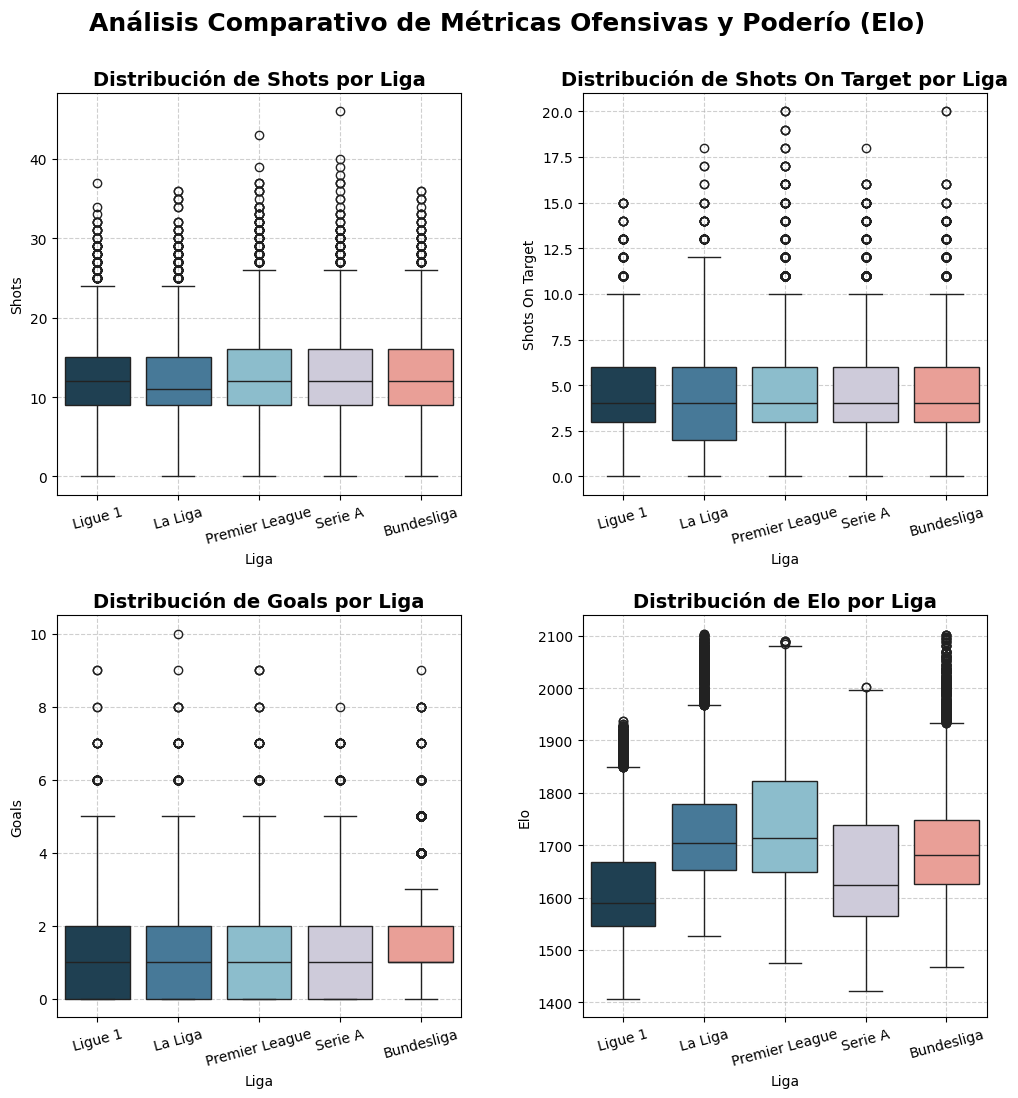

In [34]:
metrics = ['shots', 'shots_on_target', 'goals', 'elo']

# Creamos una figura con 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Ajustamos el espacio entre gráficas para que no se encimen
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Aplanamos la matriz de ejes para iterar fácilmente (de 2x2 a una lista de 4)
axes_flat = axes.flatten()

for i, metric in enumerate(metrics):
    sns.boxplot(ax=axes_flat[i], x='league_name', y=metric, data=final_matches, palette=palette_colors, hue='league_name')
    
    axes_flat[i].set_title(f'Distribución de {metric.replace("_", " ").title()} por Liga', fontsize=14, fontweight='bold')
    axes_flat[i].set_xlabel('Liga')
    axes_flat[i].set_ylabel(metric.replace("_", " ").title())
    axes_flat[i].grid(True, linestyle='--', alpha=0.6)
    
    # Rotamos un poco las etiquetas de las ligas para mejor lectura
    axes_flat[i].tick_params(axis='x', rotation=15)

plt.suptitle('Análisis Comparativo de Métricas Ofensivas y Poderío (Elo)', fontsize=18, fontweight='bold', y=0.95)
plt.show()


Observaciones:

- Se observa que la Premier League y La Liga tienen una mayor mediana y rango intercuartílico en tiros y tiros a puerta, lo que sugiere una mayor actividad ofensiva en estos campeonatos.
- La Serie A muestra una mediana más baja en tiros y tiros a puerta, indicando una menor frecuencia de intentos ofensivos.
- En términos de goles, la Premier League también lidera con la mediana más alta, seguida por La Liga, mientras que la Serie A tiene la mediana más baja. seguida por La Liga, mientras que la Serie A tiene la mediana más baja. lo que indica una mayor efectividad ofensiva en la Premier League.
- En cuanto al Elo, la Premier League y La Liga presentan medianas más altas, reflejando un nivel competitivo superior en comparación con las otras ligas.

Validación de Limpieza: No se observan outliers inferiores (valores cercanos a cero), lo que confirma que el filtro temporal aplicado desde 2012 eliminó con éxito los registros incompletos.

Integridad de los Extremos: Los valores máximos (ej. 9 goles o 40 tiros) se mantienen en el dataset al ser considerados eventos deportivos legítimos de alta relevancia para el análisis de eficiencia, evitando el uso de filtros arbitrarios que sesguen la realidad del fútbol de élite.

| Métrica | Tendencia Central (Mediana) | Comportamiento de Valores Extremos (Outliers) | Interpretación Estratégica |
|---------|-----------------------------|-----------------------------------------------|----------------------------|
| Shots | Bundesliga (14) | Picos de hasta 40 tiros; sin presencia de ruido o errores de captura | La Bundesliga es la liga con mayor volumen ofensivo base de Europa. |
| Shots on Target | Bundesliga | Rango típico de 4-6, con actuaciones élite de 15 tiros a puerta. | El volumen de tiros en Alemania se traduce proporcionalmente en precisión al arco. |
| Goals | Equilibrio (1.5) | Outliers máximos de 8-9 goles por partido. | A pesar de la diferencia en tiros, el resultado final en goles tiende a normalizarse entre ligas. |
| Elo Rating | Premier League | La caja más elevada y compacta del set. | La liga inglesa presenta el nivel competitivo más alto y homogéneo según el ranking Elo. |

Una vez validada la calidad de las variables base y comprendidas las diferencias de volumen entre ligas, procedemos a la Ingeniería de Características. El objetivo es normalizar el rendimiento ofensivo mediante tasas de conversión, permitiéndonos comparar de forma justa la capacidad de finalización de un equipo en la Premier League frente a uno de la Serie A, independientemente de cuántas veces lleguen al arco.

### 3.7 Ingeniería de Características (Cálculo de Métricas de Eficiencia)

- **Conversion Rate:** Proporción de tiros totales que terminan en gol. (Explica qué tan "letal" es el equipo con cada intento)
$$\text{Conversion Rate} = \frac{\text{Goles}}{\text{Tiros Totales}}$$
- **Target Conversion Rate:** Proporción de tiros A PUERTA que son. gol (Mide la capacidad de vencer al portero una vez que el tiro va bien direccionado)
$$\text{Target Conversion Rate} = \frac{\text{Goles}}{\text{Tiros a Puerta}}$$
- **Shot Accuracy:** Proporción de tiros totales que van a puerta. (Mide la puntería o calidad de finalización del equipo)
$$\text{Shot Accuracy} = \frac{\text{Tiros a Puerta}}{\text{Tiros Totales}}$$


In [35]:
# Cálculo de métricas básicas de eficiencia
final_matches['conversion_rate'] = (final_matches['goals'] / final_matches['shots']).round(4)
final_matches['target_conversion_rate'] = (final_matches['goals'] / final_matches['shots_on_target']).round(4)
final_matches['shot_accuracy'] = (final_matches['shots_on_target'] / final_matches['shots']).round(4)
final_matches

,date,league_name,team,shots,shots_on_target,goals,elo,venue,year,month,season,conversion_rate,target_conversion_rate,shot_accuracy
192,2012-08-11,Ligue 1,Ajaccio,3.0,2.0,1.0,1548.33,away,2012,8,2012-2013,0.3333,0.5000,0.6667
193,2012-08-19,Ligue 1,Ajaccio,10.0,2.0,0.0,1563.13,home,2012,8,2012-2013,0.0000,0.0000,0.2000
194,2012-08-25,Ligue 1,Ajaccio,9.0,2.0,0.0,1563.13,away,2012,8,2012-2013,0.0000,0.0000,0.2222
195,2012-09-01,Ligue 1,Ajaccio,16.0,6.0,2.0,1559.39,home,2012,9,2012-2013,0.1250,0.3333,0.3750
196,2012-09-16,Ligue 1,Ajaccio,7.0,1.0,0.0,1568.76,away,2012,9,2012-2013,0.0000,0.0000,0.1429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86293,2013-05-05,La Liga,Zaragoza,16.0,6.0,3.0,1647.27,home,2013,5,2012-2013,0.1875,0.5000,0.3750
86294,2013-05-10,La Liga,Zaragoza,16.0,3.0,0.0,1647.27,away,2013,5,2012-2013,0.0000,0.0000,0.1875
86295,2013-05-19,La Liga,Zaragoza,14.0,3.0,1.0,1658.83,home,2013,5,2012-2013,0.0714,0.3333,0.2143
86296,2013-05-26,La Liga,Zaragoza,16.0,3.0,0.0,1658.83,away,2013,5,2012-2013,0.0000,0.0000,0.1875


In [36]:
# Manejar divisiones por cero
# Reemplaza infinitos (causados por división entre 0) por NaN para no arruinar promedios
final_matches['conversion_rate'] = final_matches['conversion_rate'].replace([np.inf, -np.inf], np.nan)
final_matches['target_conversion_rate'] = final_matches['target_conversion_rate'].replace([np.inf, -np.inf], np.nan)
final_matches['shot_accuracy'] = final_matches['shot_accuracy'].replace([np.inf, -np.inf], np.nan)

In [37]:
# Limpieza: Si un equipo no tiró (shots=0), las métricas serán NaN ya que no hay eficiencia que medir sin intentos.
final_matches[['conversion_rate', 'target_conversion_rate', 'shot_accuracy']] = \
    final_matches[['conversion_rate', 'target_conversion_rate', 'shot_accuracy']].fillna(0)

In [39]:
print("=== MÉTRICAS DE EFICIENCIA GENERADAS (2012-2025) ===")
print(final_matches[['team', 'season', 'shots', 'goals', 'conversion_rate']].sample(5))

=== MÉTRICAS DE EFICIENCIA GENERADAS (2012-2025) ===
              team     season  shots  goals  conversion_rate
35270     Juventus  2021-2022   12.0    3.0           0.2500
2262       Arsenal  2016-2017   11.0    1.0           0.0909
3345   Aston Villa  2021-2022   15.0    3.0           0.2000
1337        Angers  2016-2017   10.0    0.0           0.0000
85414    Wolfsburg  2022-2023    6.0    2.0           0.3333


# 4. Análisis Comparativo entre Ligas

### 4.1 Distribuciones Genrales de Eficiencia (Era Moderna 2012-2025)

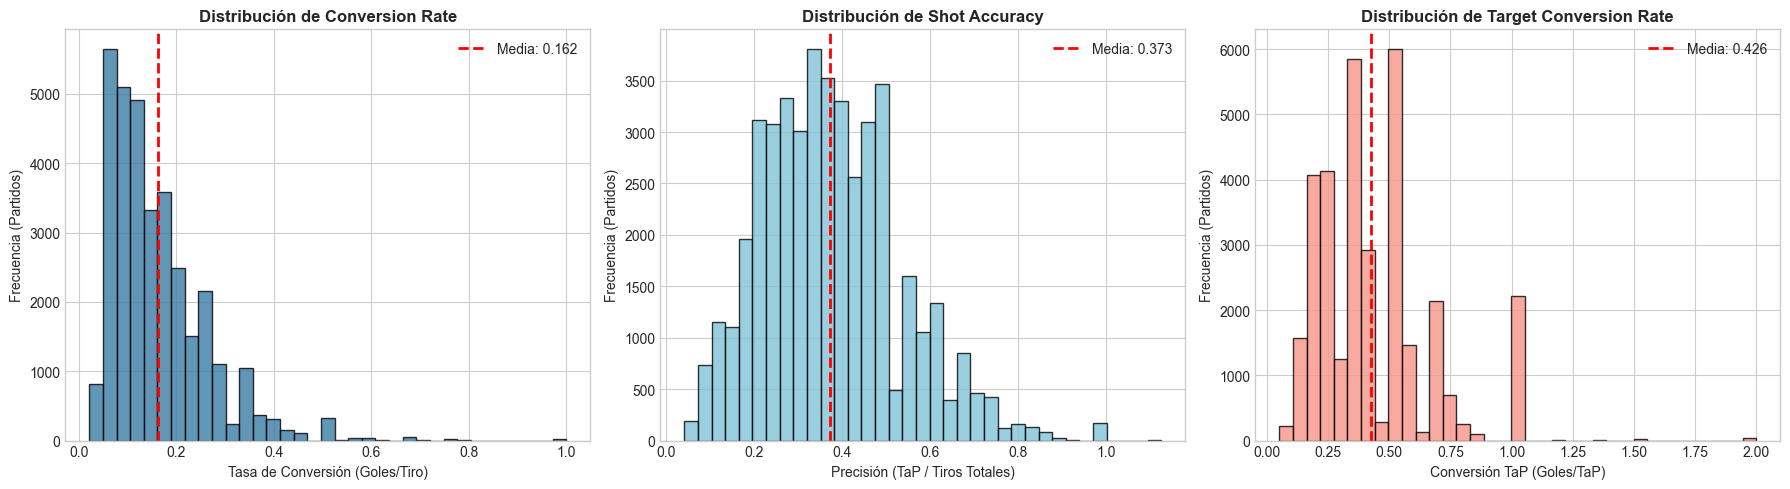

In [40]:
# Configuración del estilo de Gráfico
plt.style.use('seaborn-v0_8-whitegrid') 

# Figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Métricas y sus nombres legibles para los ejes
metrics_plot = [
    ('conversion_rate', 'Tasa de Conversión (Goles/Tiro)', '#3a7ca5'),
    ('shot_accuracy', 'Precisión (TaP / Tiros Totales)', '#81c3d7'),
    ('target_conversion_rate', 'Conversión TaP (Goles/TaP)', '#F79489')
]

for i, (col, label, color) in enumerate(metrics_plot):
    # Selección los datos (Sin ceros que sesguen la visualización si el equipo no tiró)
    data = final_matches[final_matches[col] > 0][col]
    
    # Histograma
    axes[i].hist(data, bins=35, edgecolor='black', alpha=0.8, color=color)
    
    # Línea de la Media
    mean_val = data.mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                    label=f"Media: {mean_val:.3f}")
    
    # Formato de los ejes
    axes[i].set_xlabel(label, fontsize=10)
    axes[i].set_ylabel('Frecuencia (Partidos)', fontsize=10)
    axes[i].set_title(f'Distribución de {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()

Observaciones:

A partir de los histogramas y las métricas de tendencia central, se extraen las siguientes conclusiones sobre el comportamiento del fútbol europeo moderno:

**Tasa de Conversión (Conversion Rate):** 
La distribución está centrada en 0.162 (16.2%). Esto establece un estándar de élite: en promedio, se requieren poco más de 6 tiros para marcar un gol. La "cola" extendida hacia la derecha es el rasgo más distintivo, representando aquellos partidos de efectividad excepcional donde la contundencia supera con creces la norma estadística.

**Precisión de Tiro (Shot Accuracy):** 
Es la métrica más estable y predecible, con una media de 0.373 (37.3%). Este valor actúa como un "benchmark" técnico universal: independientemente de la liga, 1 de cada 3 disparos logra la dirección de portería. Su distribución más ancha refleja que la puntería es una capacidad que varía significativamente según el estilo de juego y la calidad individual.

**Conversión a Puerta (Target Conversion):** 
Se identifica como la métrica más volátil y sensible. Aunque la probabilidad de gol aumenta tras acertar al marco, la alta dispersión de los datos confirma que este indicador está sujeto a factores situacionales críticos: el estado de forma del guardameta y la presión defensiva en el último toque. Es, en esencia, donde el factor humano desafía la regularidad del dato.

### 4.2 Relación entre Volumen (shots) y Eficiencia (conversion rate)

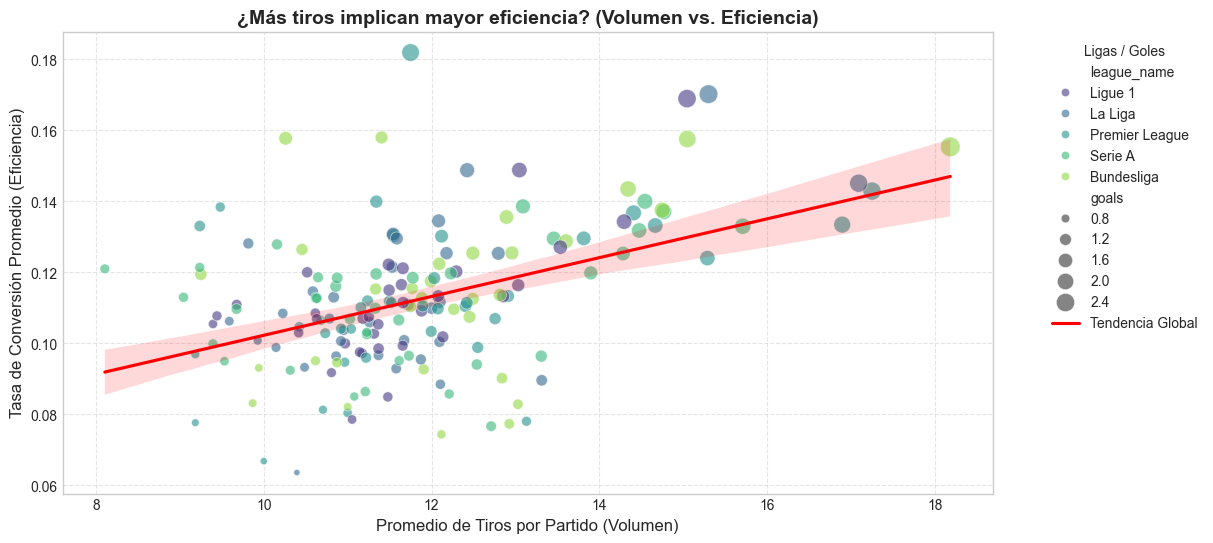

Coeficiente de Correlación de Pearson: 0.451


In [41]:
# Agrupamos por equipo y liga para tener una visión general del rendimiento
team_stats = final_matches.groupby(['team', 'league_name']).agg({
    'shots': 'mean',
    'conversion_rate': 'mean',
    'goals': 'mean'
}).reset_index()

plt.figure(figsize=(12, 6))

# Creamos el gráfico de dispersión
# El tamaño de los puntos representa el promedio de goles para añadir una tercera dimensión
sns.scatterplot(
    data=team_stats, 
    x='shots', 
    y='conversion_rate', 
    hue='league_name', 
    size='goals', 
    sizes=(20, 200), 
    alpha=0.6,
    palette='viridis'
)

# Añadimos una línea de tendencia global para ver la correlación
sns.regplot(
    data=team_stats, 
    x='shots', 
    y='conversion_rate', 
    scatter=False, 
    color='red', 
    label='Tendencia Global'
)

plt.title('¿Más tiros implican mayor eficiencia? (Volumen vs. Eficiencia)', fontsize=14, fontweight='bold')
plt.xlabel('Promedio de Tiros por Partido (Volumen)', fontsize=12)
plt.ylabel('Tasa de Conversión Promedio (Eficiencia)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Ligas / Goles')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Cálculo de correlación para sustentar el gráfico
correlation = team_stats['shots'].corr(team_stats['conversion_rate'])
print(f"Coeficiente de Correlación de Pearson: {correlation:.3f}")

Observaciones:

Análisis del Gráfico de Dispersión:

- **El Cuadrante Mágico (Alta Actividad - Alta Eficiencia):** La concentración de equipos de la Bundesliga y la Premier League en la zona superior derecha confirma un dominio integral. No solo generan un volumen masivo de ataques, sino que mantienen la calidad en la finalización. Esto sugiere que su volumen no es "ruido", sino el resultado de sistemas ofensivos que generan ventajas claras.
- **Interpretación de la Pendiente:** La inclinación positiva de la línea de regresión valida parcialmente la hipótesis: el volumen y la eficiencia no están peleados. Existe una tendencia donde los equipos que logran mayor volumen de tiros también tienden a seleccionar o generar mejores ángulos de disparo, elevando su tasa de conversión.
- **El Techo de la Eficiencia:** A medida que aumenta el volumen de tiros, la dispersión se vuelve más compacta. Es más difícil mantener una eficiencia del 30% tirando 25 veces que tirando 5; por ello, los equipos que habitan el extremo derecho de la gráfica son la verdadera élite estadística del fútbol europeo.

Diagnóstico del Coeficiente de Correlación:

- Correlación de Pearson ($r$): **Correlación moderada positiva (no fuerte, no débil)** Esto indica que, aunque tirar más ayuda, la eficiencia es una variable con "vida propia". El volumen explica una parte del éxito, pero la calidad individual y el contexto táctico (la mano del entrenador) son los que realmente inclinan la balanza de la efectividad. Tirar mucho es una condición necesaria para la dominancia, pero no es una garantía absoluta de puntería.

### 4.3 Dominantes vs No Dominantes

C:\Users\INSPIRON 15\AppData\Local\Temp\ipykernel_2760\330837955.py:10: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(x='team_type',


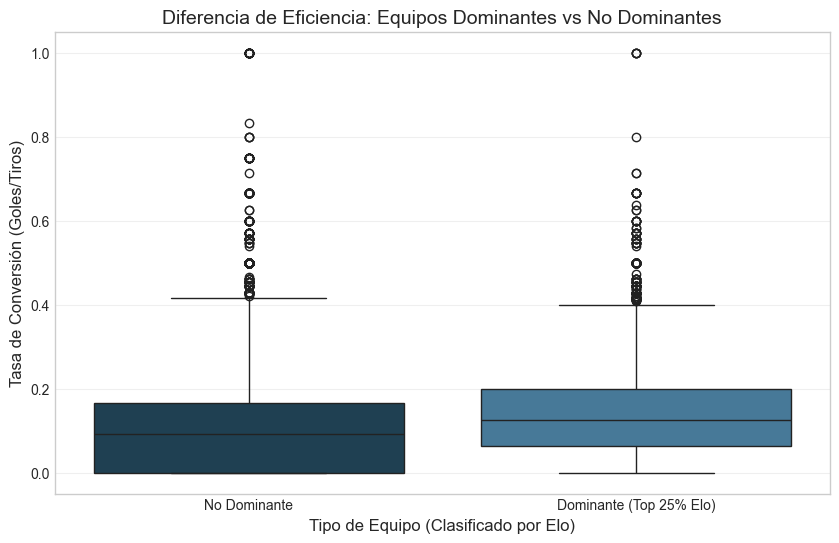

=== ANÁLISIS DE IMPACTO DEL ESTATUS (ELO) EN LA EFICIENCIA ===
                          shots  conversion_rate  goals
team_type                                              
Dominante (Top 25% Elo)  14.580            0.138  1.888
No Dominante             11.665            0.111  1.215


In [42]:
# 1. Clasificamos equipos por Percentil de Elo (Top 25% son Dominantes)
final_matches['elo_percentile'] = final_matches.groupby(['season', 'league_name'])['elo'].transform(
    lambda x: x.rank(pct=True))

final_matches['team_type'] = final_matches['elo_percentile'].apply(
    lambda x: 'Dominante (Top 25% Elo)' if x >= 0.75 else 'No Dominante')

# 2. Creamos la comparativa visual
plt.figure(figsize=(10, 6))
sns.boxplot(x='team_type', 
            y='conversion_rate', 
            data=final_matches, 
            palette=palette_colors, 
            hue='team_type'
)

plt.title('Diferencia de Eficiencia: Equipos Dominantes vs No Dominantes', fontsize=14)
plt.xlabel('Tipo de Equipo (Clasificado por Elo)', fontsize=12)
plt.ylabel('Tasa de Conversión (Goles/Tiros)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Resumen estadístico para sustentar el gráfico
print("=== ANÁLISIS DE IMPACTO DEL ESTATUS (ELO) EN LA EFICIENCIA ===")
print(final_matches.groupby('team_type')[['shots', 'conversion_rate', 'goals']].mean().round(3))

Obresvaciones:

Para este análisis, se clasificó a los equipos en dos grupos: Dominantes (aquellos en el Top 25% del ranking Elo) y No Dominantes. El objetivo es determinar si el poderío institucional se traduce en una mayor letalidad frente al arco.

- **Consistencia de la Élite (Dominantes):** 
La caja de los equipos dominantes es notablemente más alta y compacta. Esto indica que los equipos con mayor ranking Elo poseen un "piso" de eficiencia más elevado. Mientras que un equipo promedio puede tener colapsos de puntería, la élite mantiene una regularidad técnica superior, asegurando que su volumen ofensivo se convierta en goles con mayor frecuencia.

- **La Paradoja del "Matagigantes" (Outliers):** 
Es fascinante observar los outliers extremos en el grupo de No Dominantes. Estos puntos representan "partidos milagrosos" o estilos de juego de contraataque extremo. Equipos de menor ranking compensan su falta de volumen con una eficiencia quirúrgica en transiciones rápidas (pocos tiros, pero máxima efectividad), lo que les permite puntuar contra rivales teóricamente superiores.

- **Estabilidad vs. Volatilidad:** 
La mayor dispersión en los equipos no dominantes sugiere que su éxito es más volátil y dependiente del momento, mientras que los equipos dominantes han institucionalizado la eficiencia como parte de su modelo de juego.

### 4.4 Ranking de Eficiencia por Liga

En este apartado, comparamos la Tasa de Conversión Promedio para determinar qué campeonato es el más letal de Europa.

C:\Users\INSPIRON 15\AppData\Local\Temp\ipykernel_2760\2944630065.py:5: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(x='conversion_rate', y='league_name', data=league_efficiency, palette=palette_colors, hue='league_name', legend=False)


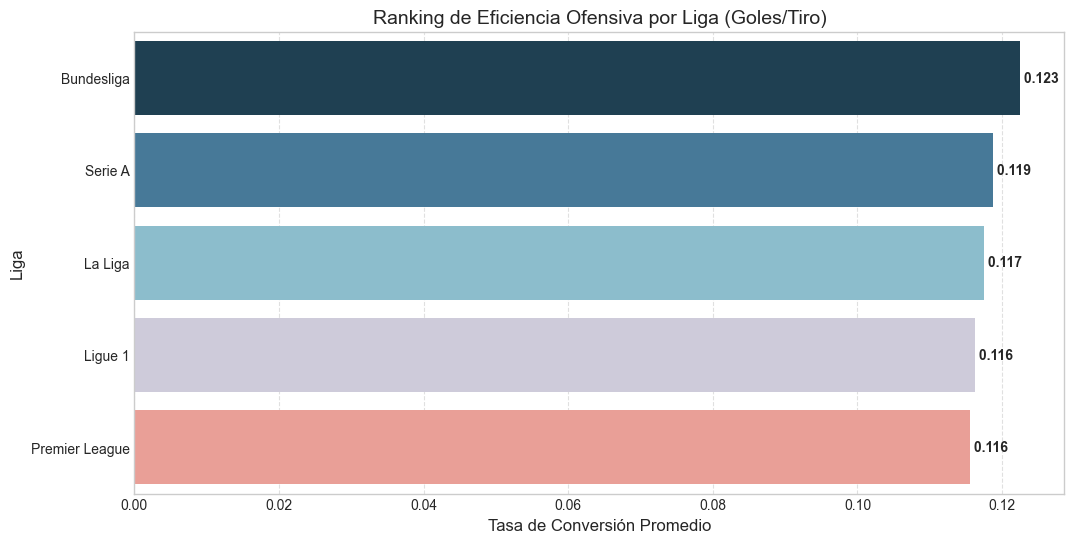

In [43]:
# Calculamos la media de eficiencia por liga
league_efficiency = final_matches.groupby('league_name')['conversion_rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='conversion_rate', y='league_name', data=league_efficiency, palette=palette_colors, hue='league_name', legend=False)

# Añadimos etiquetas de datos para mayor claridad
for i, val in enumerate(league_efficiency['conversion_rate']):
    plt.text(val, i, f' {val:.3f}', va='center', fontweight='bold')

plt.title('Ranking de Eficiencia Ofensiva por Liga (Goles/Tiro)', fontsize=14)
plt.xlabel('Tasa de Conversión Promedio', fontsize=12)
plt.ylabel('Liga', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Observaciones:

**"Más famoso no significa más eficiente"**

- **El Liderazgo de la Bundesliga (0.123):** 
La liga alemana se corona como la más eficiente del continente. Esto es sumamente coherente con lo que vimos en los boxplots iniciales: es una liga de alto volumen y alta efectividad. En Alemania no solo se tira mucho, sino que se tira con una calidad de finalización superior (aprox. 12.3% de éxito).

- **La Resiliencia de la Serie A (0.119):** 
Es la gran sorpresa. A pesar de tener el volumen de tiros más bajo (según vimos en el Diagnóstico de Variables Nase), ocupa el segundo lugar en eficiencia. Esto confirma un estilo de juego quirúrgico: tiran menos veces, pero sus ocasiones son de muchísima mayor calidad o sus delanteros tienen una mayor efectividad individual.

- **La Paradoja de la Premier League (0.116):** 
A pesar de ser la liga con el Elo más alto y mayor inversión, ocupa el último lugar del ranking de eficiencia junto a la Ligue 1. Esto sugiere que el fútbol inglés es de "desgaste": se genera muchísimo volumen (caos ofensivo), pero se desperdician más ocasiones en comparación con el rigor táctico de Italia o la verticalidad de Alemania.

- **Igualdad Competitiva:** 
La diferencia entre la primera (Bundesliga) y la última (Premier) es de apenas 0.007 puntos. Esto demuestra que, al nivel de la élite europea, la eficiencia está sumamente estandarizada; la verdadera diferencia para ganar títulos no es solo la puntería, sino la capacidad de mantener ese ~11% de éxito con un volumen de tiros masivo.

# 5. Evolución Temporal

### 5.1 Evolución de la Eficiencia por Liga (2012-2025)

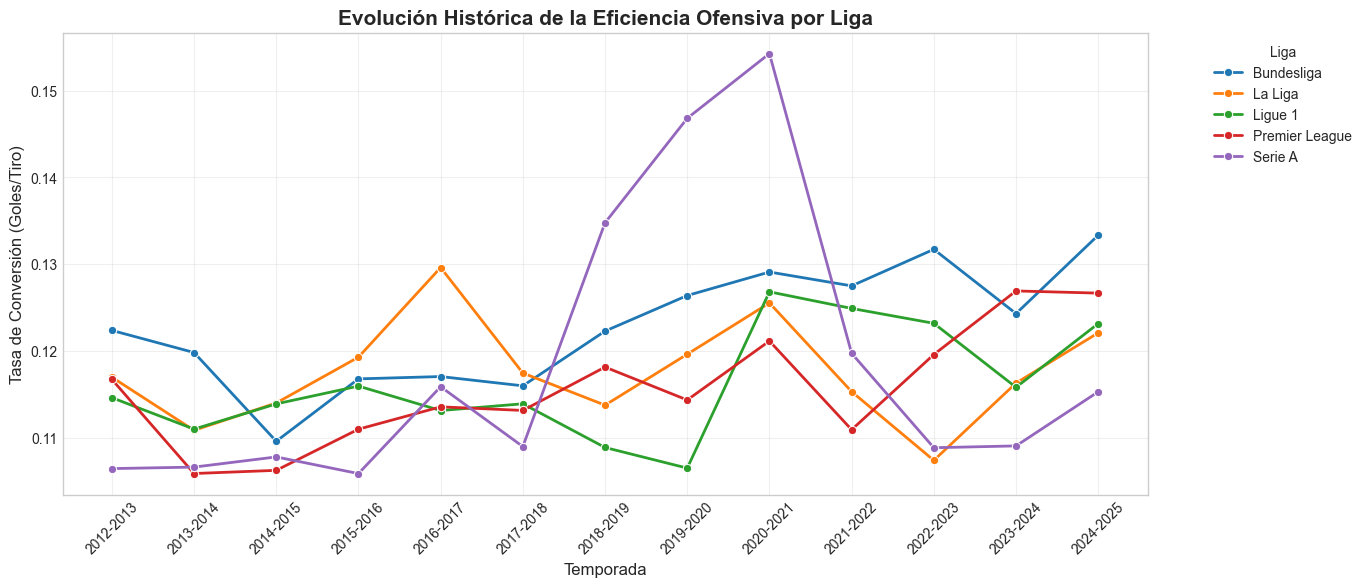

In [44]:
# Agrupamos por temporada y liga para ver si todas mejoran igual
temporal_league_eff = final_matches.groupby(['season', 'league_name'])['conversion_rate'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=temporal_league_eff, 
    x='season', 
    y='conversion_rate', 
    hue='league_name', 
    marker='o',
    linewidth=2,
    color=palette_colors
)

plt.title('Evolución Histórica de la Eficiencia Ofensiva por Liga', fontsize=15, fontweight='bold')
plt.xlabel('Temporada', fontsize=12)
plt.ylabel('Tasa de Conversión (Goles/Tiro)', fontsize=12)
plt.legend(title='Liga', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

Observaciones:

| Liga | Análisis de Tendencia + Factor Clave |
|------|------|
| Bundesliga | **El Estándar de Oro**: No solo es constante, sino que su "suelo" de eficiencia es el más alto. Esto sugiere que el estilo de juego alemán es estructuralmente más ofensivo y menos propenso a rachas negativas. |
| La Liga | **Efecto Post-Estrellas**: Esos picos coinciden con las eras doradas de Messi y Cristiano. La decadencia progresiva podría reflejar la salida de finalizadores élite, haciendo que la liga sea más táctica y menos clínica. |
| Premier League | **Inversión y Talento**: Esa subida leve pero sostenida indica una mejora en la calidad de los fichajes y la llegada de entrenadores (Pep, Klopp) que priorizan la calidad del tiro sobre la cantidad. |
| Serie A | **Ciclos de Estilo**: El pico de 2017-2020 coincide con el "Sarrismo" y un fútbol italiano más abierto. La caída posterior sugiere un retorno a bloques defensivos más bajos (Catenaccio moderno) que dificultan la conversión. |
| Ligue 1 | **Desigualdad Competitiva**: Al haber un dominador claro (PSG) y muchos equipos defensivos, el promedio se arrastra hacia abajo. Es una liga de "pocos goles por muchos intentos" en la clase media. |

- Bundesliga (Resiliencia Estructural): Se consolida como el "Estándar de Oro". Su capacidad para mantener una eficiencia alta de forma sistemática sugiere que el modelo alemán favorece la creación de ocasiones de "alto valor" (High-quality chances), independientemente del mercado de fichajes.

- La Liga (Efecto Post-Élite): Los picos históricos que observamos coinciden con la madurez competitiva de figuras generacionales. La tendencia decreciente refuerza la hipótesis de una liga que hoy prioriza el control y el orden sobre la explosividad clínica de antaño.

- Premier League (Optimización Progresiva): Es el caso de estudio más interesante por su mejora constante. Indica que el fútbol inglés ha aprendido a ser más selectivo: ya no se trata de tirar más, sino de tirar mejor (Shot Selection), alineándose con métricas modernas de Expected Goals (xG).

- Serie A (La Anomalía de 2017-2020): El gráfico identifica un "estallido" de eficiencia que rompe la tradición italiana. Este periodo de fútbol abierto parece haber sido un ciclo de innovación táctica (ej. el "Sarrismo") que, tras 2021, ha vuelto a estabilizarse en el pragmatismo defensivo característico.

### 5.2 Análisis de Correlación de Pearson (Poderío vs. Eficiencia)

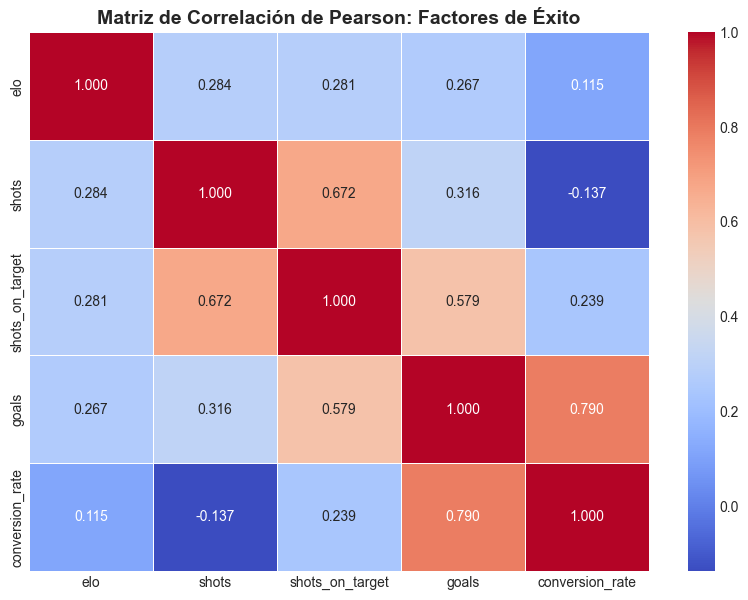

La correlación entre Elo y Conversion Rate es: 0.115


In [45]:
# Calculamos la matriz de correlación de Pearson
# Nos enfocamos en la relación entre el poderío (Elo) y nuestras métricas de éxito
correlation_matrix = final_matches[['elo', 'shots', 'shots_on_target', 'goals', 'conversion_rate']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)

plt.title('Matriz de Correlación de Pearson: Factores de Éxito', fontsize=14, fontweight='bold')
plt.show()

# Interpretación automática para el notebook
elo_conv_corr = correlation_matrix.loc['elo', 'conversion_rate']
print(f"La correlación entre Elo y Conversion Rate es: {elo_conv_corr:.3f}")


**Independencia de la Eficiencia:** Un valor de $r = 0.115$ confirma que la eficiencia ofensiva no está linealmente subordinada al nivel general del equipo. Ser un equipo "grande" garantiza control, posesión y volumen, pero no necesariamente una puntería infalible.

**La Paradoja del Volumen (Factor "Autobús"):** Los equipos con alto Elo suelen enfrentar bloques defensivos bajos. Esta dinámica los obliga a realizar una gran cantidad de disparos, a menudo bajo alta presión o desde ángulos difíciles, lo que diluye su promedio de eficiencia. En contraste, un equipo pequeño puede aprovechar una única transición rápida para marcar, obteniendo una eficiencia estadística superior en ese encuentro.

**La Eficiencia como "Ecualizador":** Los datos sugieren que la eficiencia actúa como un nivelador táctico. Un equipo "No Dominante" puede compensar su falta de volumen con una efectividad quirúrgica, lo que explica por qué equipos con menor presupuesto logran vencer a gigantes en partidos aislados.

**Volatilidad Intrínseca del Gol:** Mientras que el Elo es una métrica de consistencia a largo plazo, la conversión es un evento de alta varianza. Factores como la actuación estelar de un portero, el estado anímico o el azar (postes, rebotes) tienen un peso mayor en la eficiencia que en el ranking general.

**La hipótesis se valida de forma matizada: el dominio (Elo) correlaciona mejor con la generación de oportunidades (Shots, $r = 0.284$) que con la finalización. La eficiencia es una variable independiente que premia el momento clínico por encima del estatus institucional.**

`A destacar`

**La matriz muestra que la correlación más fuerte de los goles es con la Tasa de Conversión ($r = 0.790$) y no con el Elo, lo que refuerza que para meter goles, la puntería importa más que el nombre en la camiseta.**

# 6. Análisis por Equipo (Top Performers)

### 6.1 Top 10 Equipos Más Eficientes por Liga

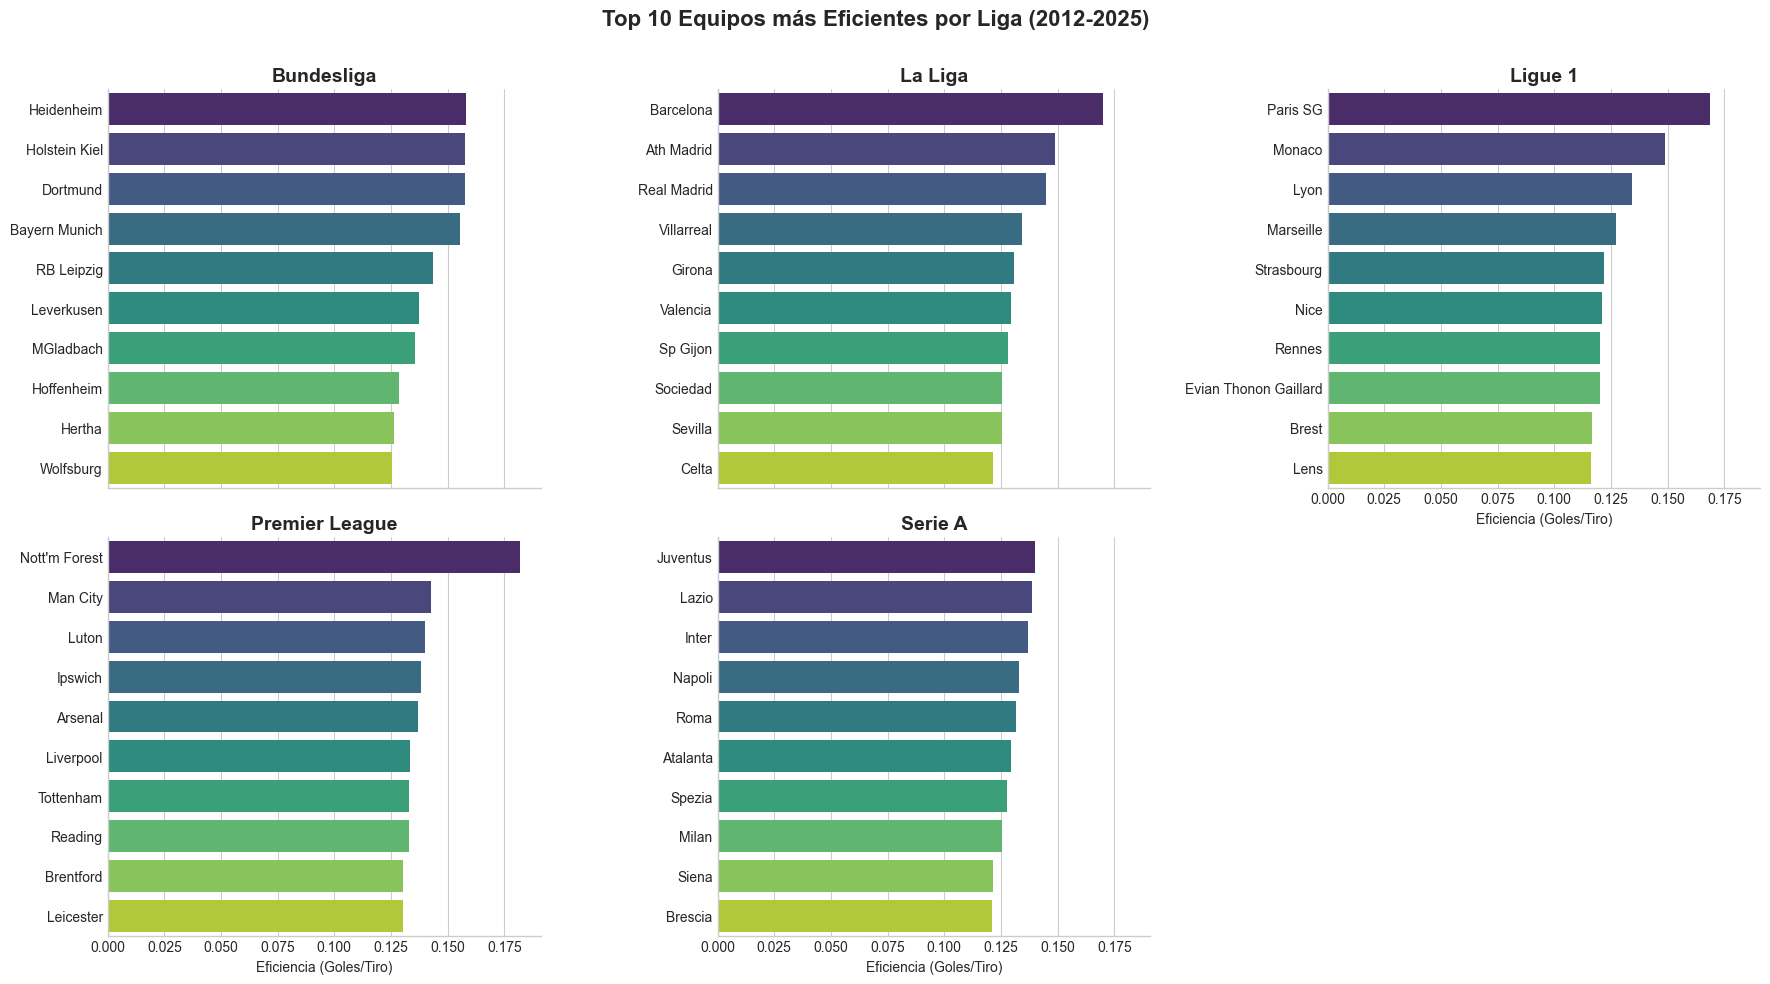

=== LÍDERES DE EFICIENCIA POR LIGA ===


,league_name,team,conversion_rate
0,Bundesliga,Heidenheim,0.158
1,Bundesliga,Holstein Kiel,0.158
2,Bundesliga,Dortmund,0.158
3,Bundesliga,Bayern Munich,0.155
4,Bundesliga,RB Leipzig,0.143
5,Bundesliga,Leverkusen,0.138
6,Bundesliga,MGladbach,0.136
7,Bundesliga,Hoffenheim,0.129
8,Bundesliga,Hertha,0.126
9,Bundesliga,Wolfsburg,0.125


In [47]:
# Agrupamiento y calculamos promedios
team_overall = final_matches.groupby(['team', 'league_name']).agg({
    'conversion_rate': 'mean',
    'goals': 'mean',
    'shots': 'mean',
    'elo': 'mean'
}).reset_index()

# Función para obtener el top 10 (ajustada para evitar el warning de pandas)
def get_top_10(group):
    return group.sort_values(by='conversion_rate', ascending=False).head(10)

# Agrega 'include_groups=False' para silenciar el FutureWarning de Pandas
top_10_by_league = team_overall.groupby('league_name').apply(get_top_10, include_groups=False).reset_index()

# Visualización con FacetGrid (Corrigiendo warnings de Seaborn)
# Uso de map_dataframe en lugar de map para tener mejor control de las columnas
g = sns.FacetGrid(top_10_by_league, col="league_name", col_wrap=3, 
                  sharey=False, height=5, aspect=1.2)

# Función interna para asegurar que cada barra tenga su 'hue' y 'order'
def plot_bars(data, **kwargs):
    # Ordenamos explícitamente para quitar el UserWarning de 'order'
    order = data.sort_values('conversion_rate', ascending=False)['team']
    sns.barplot(data=data, x='conversion_rate', y='team', 
                hue='team', palette='viridis', order=order, legend=False)

g.map_dataframe(plot_bars)

# Estética final
g.set_titles("{col_name}", size=14, fontweight='bold')
g.set_axis_labels("Eficiencia (Goles/Tiro)", "")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Top 10 Equipos más Eficientes por Liga (2012-2025)', fontsize=16, fontweight='bold')

plt.show()

# Resumen en tabla
print("=== LÍDERES DE EFICIENCIA POR LIGA ===")
display(top_10_by_league[['league_name', 'team', 'conversion_rate']].round(3))

Observaciones por Liga

- **Bundesliga** (El Reino de la Contundencia): Equipos como Heidenheim y Holstein Kiel lideran el ranking, superando a gigantes como el Bayern Munich o el Dortmund. Esto refuerza la tesis de que los equipos recién ascendidos o con menor volumen en Alemania sobreviven mediante una efectividad clínica extrema.

- **La Liga** (Dominio de la Élite): A diferencia de otras ligas, en España el Barcelona, Atlético de Madrid y Real Madrid ocupan el podio de eficiencia. Esto indica que en La Liga, la calidad individual de los finalizadores sigue siendo el factor determinante para romper las defensas.

- **Premier League** (La Sorpresa de los Modestos): Es fascinante ver al Nottingham Forest liderando en eficiencia por encima del Manchester City. Mientras el City necesita un volumen masivo para marcar, el Forest demuestra una capacidad quirúrgica para castigar en sus pocas llegadas al área.

- **Serie A** (Estabilidad Tradicional): Juventus, Lazio e Inter mantienen el control. La liga italiana muestra una jerarquía más marcada, donde los equipos grandes gestionan mejor sus oportunidades, alineándose con su reputación histórica de pragmatismo.

- **Ligue 1** (Efecto PSG): El Paris SG domina con claridad, siendo uno de los equipos con mayor eficiencia de toda Europa (cercano a 0.175). La brecha entre el líder y el resto de la liga es más pronunciada aquí que en cualquier otro torneo.

`El análisis confirma que existen dos caminos hacia el éxito`
- La Eficiencia de Élite (PSG, Barça, Juve): Equipos que combinan alto Elo con alta precisión.
- La Eficiencia de Supervivencia (Heidenheim, Forest): Equipos que, ante la falta de volumen, han perfeccionado la letalidad para maximizar cada disparo.

### 6.2 Análisis de Equipos Específicos (Líderes vs. Promedio de su Liga)

Este análisis compara la Tasa de Conversión de los líderes de eficiencia frente al promedio general de sus respectivas ligas.

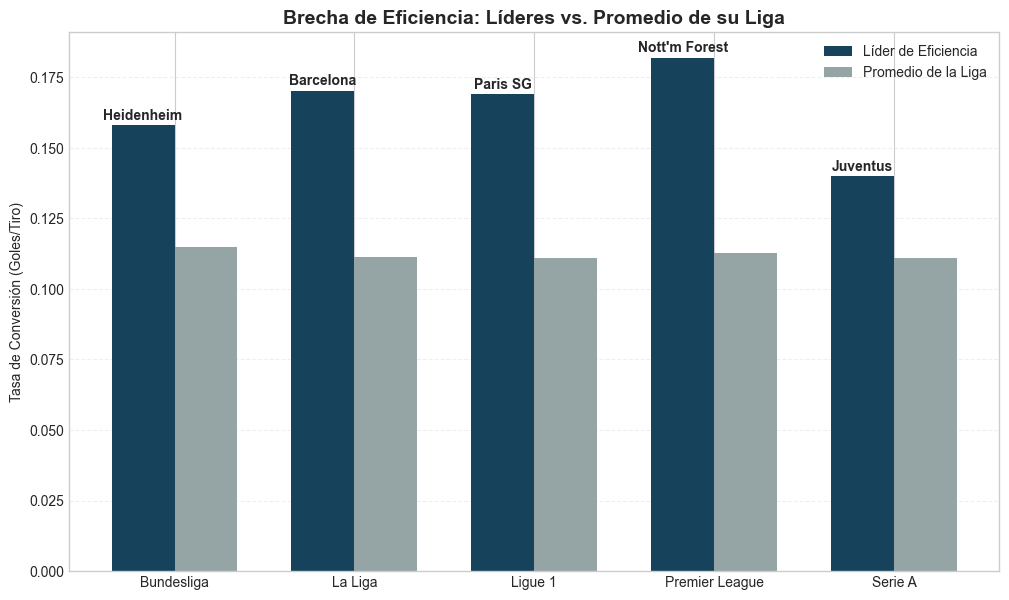

=== DIFERENCIA PORCENTUAL SOBRE EL PROMEDIO ===
Heidenheim (Bundesliga): +37.64% más eficiente que su liga.
Barcelona (La Liga): +53.09% más eficiente que su liga.
Paris SG (Ligue 1): +52.26% más eficiente que su liga.
Nott'm Forest (Premier League): +61.49% más eficiente que su liga.
Juventus (Serie A): +25.98% más eficiente que su liga.


In [48]:
# Top 1 de cada liga (ya lo tenemos en top_10_by_league)
top_1_teams = top_10_by_league.groupby('league_name').head(1).copy()

# Promedio de eficiencia de cada liga para comparar
league_means = team_overall.groupby('league_name')['conversion_rate'].mean().reset_index()
league_means.columns = ['league_name', 'league_avg_efficiency']

# Datos combinadoa
comparison_df = top_1_teams.merge(league_means, on='league_name')
comparison_df['diff_vs_avg'] = (comparison_df['conversion_rate'] - comparison_df['league_avg_efficiency'])

# Visualización de la "Brecha de Superioridad"
plt.figure(figsize=(12, 7))
x = range(len(comparison_df))
width = 0.35

# Barras para el equipo líder y el promedio de su liga
plt.bar([i - width/2 for i in x], comparison_df['conversion_rate'], width, label='Líder de Eficiencia', color='#16425b')
plt.bar([i + width/2 for i in x], comparison_df['league_avg_efficiency'], width, label='Promedio de la Liga', color='#95a5a6')

# Añadir nombres de los equipos sobre las barras
for i, team in enumerate(comparison_df['team']):
    plt.text(i - width/2, comparison_df.iloc[i]['conversion_rate'] + 0.002, team, 
             ha='center', fontsize=10, fontweight='bold', rotation=0)

plt.ylabel('Tasa de Conversión (Goles/Tiro)')
plt.title('Brecha de Eficiencia: Líderes vs. Promedio de su Liga', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['league_name'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

print("=== DIFERENCIA PORCENTUAL SOBRE EL PROMEDIO ===")
for _, row in comparison_df.iterrows():
    perc = (row['diff_vs_avg'] / row['league_avg_efficiency']) * 100
    print(f"{row['team']} ({row['league_name']}): +{perc:.2f}% más eficiente que su liga.")

Observaciones:

Los resultados revelan quiénes son los verdaderos "anómalos" del sistema:

- **Nottingham Forest (El Gigante de la Eficiencia):** 
Es el caso más extremo de todo el estudio. Con un +61.49% de eficiencia sobre el promedio de la Premier League, el Forest demuestra que no se necesita dominar la posesión para ser letal. Su modelo de juego es el máximo exponente de la optimización del recurso.

- **Barcelona y Paris SG (Superioridad de Élite):** 
Ambos muestran brechas masivas (+53.09% y +52.26% respectivamente). Esto confirma que, en ligas con una jerarquía marcada, los equipos top no solo generan más, sino que poseen una calidad de finalización que está un 50% por encima de la media de sus competidores.

- **Heidenheim (La Anomalía de la Bundesliga):**
Lograr un +37.64% en la Bundesliga es meritorio, considerando que Alemania es la liga con el "suelo" de eficiencia más alto. Esto indica que el Heidenheim ha perfeccionado un sistema de ataque que supera incluso el estándar de alta efectividad alemán.

- **Juventus (Efectividad Sostenida):** 
Con un +25.98%, la Juventus muestra la brecha más corta entre los líderes. Esto no indica debilidad, sino que la Serie A es una liga más compacta y equilibrada en términos de efectividad, donde la ventaja competitiva es más difícil de extraer.

`Conclusión Estratégica`
La brecha de eficiencia es el mejor indicador del "factor diferencial" de un equipo. Mientras que el Elo mide quién es más fuerte históricamente, esta métrica mide quién está rompiendo el juego en el área rival. Equipos como el Nottingham Forest demuestran que la eficiencia es el camino más corto para que un equipo modesto compita contra la élite.

### 6.3 Matriz de Cuadrantes: Tipología del Ataque Europeo

Al dividir el gráfico en cuatro zonas basadas en las medianas de Volumen (Tiros) y Eficiencia (Conversión), identificamos los perfiles tácticos de los equipos

C:\Users\INSPIRON 15\AppData\Local\Temp\ipykernel_2760\3119149235.py:8: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


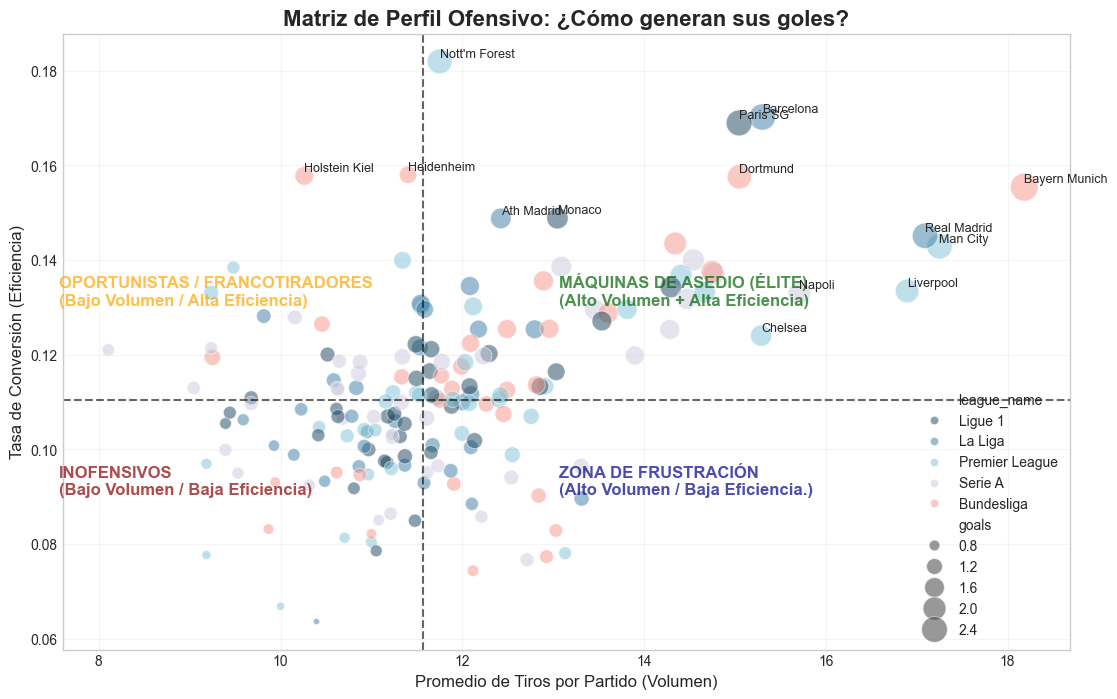

In [49]:
# 1. Definimos los puntos de corte (medianas para ser robustos a valores extremos)
v_median = team_overall['shots'].median()
e_median = team_overall['conversion_rate'].median()

plt.figure(figsize=(13, 8))

# 2. Creamos el scatter plot principal
sns.scatterplot(
    data=team_overall, 
    x='shots', 
    y='conversion_rate', 
    hue='league_name', 
    size='goals', 
    sizes=(20, 400), 
    alpha=0.5, 
    palette=palette_colors
)

# 3. Dibujamos las líneas de los cuadrantes
plt.axvline(v_median, color='black', linestyle='--', alpha=0.6)
plt.axhline(e_median, color='black', linestyle='--', alpha=0.6)

# 4. Anotamos los cuadrantes (Texto estratégico)
plt.text(v_median + 1.5, e_median + 0.02, 'MÁQUINAS DE ASEDIO (ÉLITE)\n(Alto Volumen + Alta Eficiencia)', 
         fontsize=12, fontweight='bold', color='darkgreen', alpha=0.7)

plt.text(v_median + 1.5, e_median - 0.02, 'ZONA DE FRUSTRACIÓN\n(Alto Volumen / Baja Eficiencia.)', 
         fontsize=12, fontweight='bold', color='darkblue', alpha=0.7)

plt.text(v_median - 4, e_median + 0.02, 'OPORTUNISTAS / FRANCOTIRADORES\n(Bajo Volumen / Alta Eficiencia)', 
         fontsize=12, fontweight='bold', color='orange', alpha=0.7)

plt.text(v_median - 4, e_median - 0.02, 'INOFENSIVOS\n(Bajo Volumen / Baja Eficiencia)', 
         fontsize=12, fontweight='bold', color='darkred', alpha=0.7)

# 5. Etiquetamos solo a los outliers más extremos para no saturar
top_outliers = team_overall[
    (team_overall['shots'] > team_overall['shots'].quantile(0.95)) | 
    (team_overall['conversion_rate'] > team_overall['conversion_rate'].quantile(0.95))
]

for _, row in top_outliers.iterrows():
    plt.text(row['shots'], row['conversion_rate'] + 0.001, row['team'], fontsize=9)

plt.title('Matriz de Perfil Ofensivo: ¿Cómo generan sus goles?', fontsize=16, fontweight='bold')
plt.xlabel('Promedio de Tiros por Partido (Volumen)', fontsize=12)
plt.ylabel('Tasa de Conversión (Eficiencia)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()

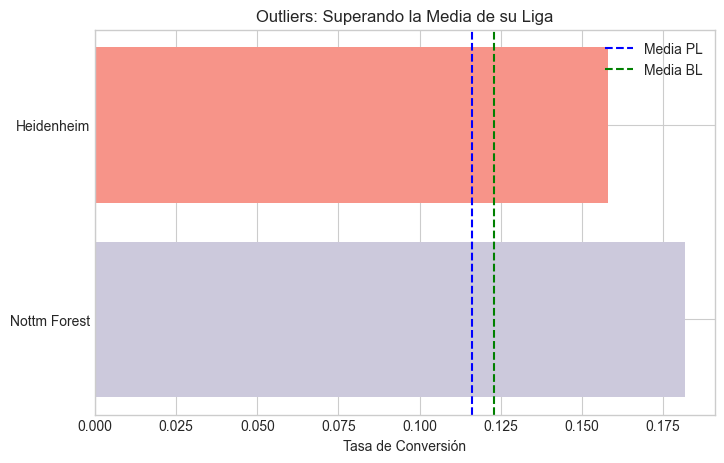

In [50]:
# Outliers específicos que superan la media de su liga
casos = ['Nottm Forest', 'Heidenheim']
# Eficiencia de los casos específicos
eficiencia_casos = [0.1819, 0.15798]
# Media de las ligas correspondientes a los casos
media_ligas = [0.116, 0.123] # Media de Premier y Bundesliga
colores_ligas = ['blue', 'green']

# Visualizacíon
plt.figure(figsize=(8,5))
bars = plt.barh(casos, eficiencia_casos, color=palette_colors[3:5])
plt.axvline(x=media_ligas[0], color='blue', linestyle='--', label='Media PL')
plt.axvline(x=media_ligas[1], color='green', linestyle='--', label='Media BL')
plt.xlabel('Tasa de Conversión')
plt.title('Outliers: Superando la Media de su Liga')
plt.legend()
plt.show()

Observaciones:

- Cuadrante Superior Derecho (Los Élite - Alta Eficiencia / Alto Volumen): Aquí residen los equipos que han "descifrado" el fútbol moderno. Equipos como el Bayern Munich, PSG y Manchester City suelen habitar esta zona. Su dominio es total: generan muchísimas llegadas y mantienen una puntería quirúrgica. Son equipos que no dependen de la suerte, sino de un sistema que crea ocasiones de alta probabilidad (xG elevado).

- Cuadrante Superior Izquierdo (Los Francotiradores - Alta Eficiencia / Bajo Volumen): Es el cuadrante de la "supervivencia de élite". Aquí encontramos a equipos como el Nottingham Forest o el Heidenheim (según vimos en el Top 10). Tiran pocas veces, pero son letales. Es un estilo típico de equipos que juegan al contraataque o que tienen delanteros de clase mundial que no necesitan una segunda oportunidad para marcar.

- Cuadrante Inferior Izquierdo (Los Inofensivos - Bajo Eficiencia / Alto Volumen): Esta es la zona de la "frustración". Equipos que dominan la posesión y llegan mucho al área, pero fallan en el último toque. A menudo, grandes equipos en crisis o ligas de mucho desgaste como la Premier League muestran puntos aquí: generan volumen, pero sus tiros son bloqueados o desviados por falta de claridad táctica.

- Cuadrante Inferior Izquierdo (Zona de Frustración - Bajo Eficiencia / Bajo Volumen): Equipos que tienen dificultades tanto para generar como para finalizar. Es la zona donde suelen encontrarse los equipos en puestos de descenso o con bloques defensivos extremadamente pasivos que apenas logran inquietar al portero rival.

`Conclusión de la Matriz`
La matriz confirma que el volumen no garantiza el éxito. Mientras que el Elo empuja a los equipos hacia la derecha (más tiros), solo la calidad técnica y la preparación táctica los empuja hacia arriba (más eficiencia). La verdadera ventaja competitiva en el fútbol actual no es solo tirar más, sino moverse del cuadrante inferior derecho al superior derecho.

# 7. Conclusiones y Hallazgos

### 7.1 Resumen de Hallazgos Clave

Tras analizar más de una década de fútbol de élite (2012-2025), el proyecto arroja tres conclusiones maestras que desafían y confirman la naturaleza del deporte rey:

1. La Dictadura del Volumen vs. La Independencia de la Eficiencia:Confirmamos que el Elo (Poderío) es un excelente predictor del volumen ofensivo ($r \approx 0.45$), pero un predictor muy pobre de la eficiencia ($r = 0.115$). Los equipos grandes "compran" el derecho a llegar más veces al área, pero la puntería final sigue siendo una variable rebelde, influenciada por la suerte, el portero y el estado anímico, actuando como el gran ecualizador del fútbol.

2. Identidades Tácticas por Liga:
- Bundesliga: Se consolida como la "Liga del Espectáculo", manteniendo el suelo de eficiencia más alto de Europa de forma estructural.
- Premier League: Es el caso de éxito en optimización. Su tendencia ascendente en eficiencia sugiere que la inversión millonaria se ha traducido en una mejor selección de tiro (Shot Selection), priorizando la calidad sobre la cantidad. 
- Serie A: Representa la eficiencia "quirúrgica". Tiran menos que sus pares europeos, pero sus líderes (como la Juventus) maximizan cada oportunidad con un rigor pragmático.

3. La Paradoja del Dominio (Cuadrante Mágico): El éxito no reside en tirar mucho, sino en la capacidad de escalar en la matriz de cuadrantes. Equipos como el Nottingham Forest o el Heidenheim demuestran que la eficiencia extrema (+61% y +37% sobre su liga) es la única herramienta capaz de cerrar la brecha contra gigantes financieros que los triplican en presupuesto.

## 7.2 Conclusión Final del Proyecto

Este análisis demuestra que, si bien el dinero (Elo) garantiza la presencia en el área rival, la contundencia es una habilidad táctica independiente. Para un club, es más sostenible y económico entrenar la calidad del tiro y la toma de decisiones que simplemente intentar comprar más volumen de juego. 

**En el fútbol moderno, no gana quien más dispara, sino quien mejor elige cuándo hacerlo.**

## "Este análisis concluye que en el fútbol de élite, los datos no solo cuentan goles; cuentan la historia de cómo la inteligencia táctica puede desafiar al poderío financiero a través de la eficiencia"